<a href="https://colab.research.google.com/github/BharathReddyRamasani/Weekly_Assignments_CEI/blob/main/Week6_BharathReddy_cvr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Build a deep learning model that can remove noise from images using an autoencoder on MNIST

# Project 1: Image Denoising using CNN Autoencoder on MNIST

## Objective

The objective of this project is to build a Convolutional Autoencoder capable of removing Gaussian noise from handwritten digit images.

The model learns to reconstruct clean images from noisy inputs by minimizing reconstruction loss.

---

## Learning Outcomes

After completing this project, you will understand:

- Autoencoders
- CNN Encoder
- CNN Decoder
- Image Reconstruction
- Image Denoising
- Gaussian Noise
- Adam Optimizer
- Learning Rate Scheduler
- Early Stopping
- Model Checkpointing
- PSNR
- SSIM

---

## Workflow

1. Download MNIST Dataset
2. Explore Dataset
3. Preprocess Images
4. Add Gaussian Noise
5. Build Dataset
6. Create CNN Autoencoder
7. Train Model
8. Validate Model
9. Evaluate Model
10. Visualize Reconstructions
11. Save Best Model

Cell 2 (Install Dependencies)

In [41]:
!pip install -q kagglehub
!pip install -q torchsummary
!pip install -q scikit-image

Cell 3 (Import Libraries)

In [42]:
import os
import random
import copy
import warnings
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchsummary import summary
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

warnings.filterwarnings("ignore")

# Reproducibility

Machine learning experiments should be reproducible.

To ensure identical results across multiple runs:

- Fix Python seed
- Fix NumPy seed
- Fix PyTorch seed
- Disable CuDNN benchmarking

In [43]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", DEVICE)

Device : cuda


# Download MNIST Dataset

The MNIST dataset is downloaded using KaggleHub.

Dataset contains:

- 60,000 training images
- 10,000 testing images

Each image is

28 × 28 grayscale.

In [44]:
path = kagglehub.dataset_download("awsaf49/mnist-dataset")

print(path)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
/kaggle/input/mnist-dataset


In [45]:
import numpy as np
import tensorflow as tf # Import tensorflow for loading MNIST

# Load MNIST data using Keras datasets
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


# Train / Validation Split

To prevent **data leakage**, the original training data is split into:

- Training Set (80%)
- Validation Set (20%)

The test dataset remains untouched until final evaluation.

In [46]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train,
)

print("Train :", x_train.shape)
print("Validation :", x_val.shape)
print("Test :", x_test.shape)

Train : (48000, 28, 28)
Validation : (12000, 28, 28)
Test : (10000, 28, 28)


 (Normalize Images)

In [47]:
x_train = x_train.astype(np.float32) / 255.0
x_val = x_val.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# Dataset Exploration

Let's visualize a few images from the training dataset.

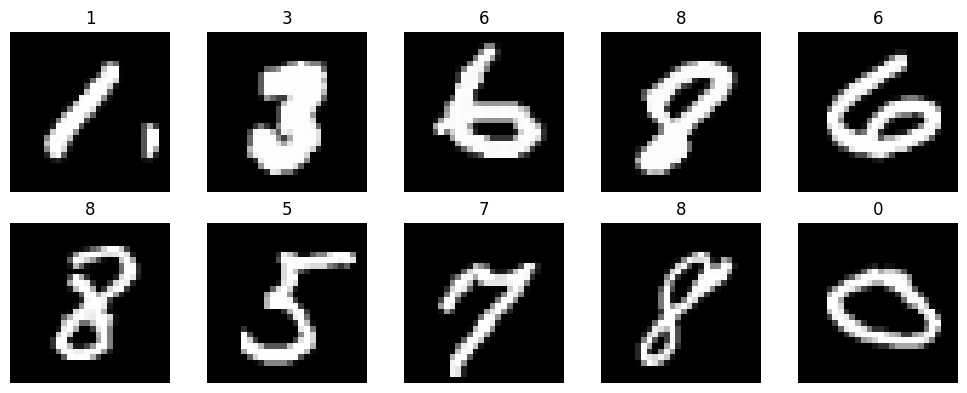

In [48]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
plt.tight_layout()

plt.show()

# Gaussian Noise Generation

Instead of corrupting images randomly every epoch, we generate noisy images using Gaussian noise.

Advantages:

- More stable training
- Controlled corruption
- Better reproducibility

In [49]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=images.shape,
    )
    noisy = np.clip(noisy, 0., 1.)
    return noisy

In [50]:
train_noisy = add_noise(x_train)
val_noisy = add_noise(x_val)
test_noisy = add_noise(x_test)

# Visualize Clean vs Noisy Images

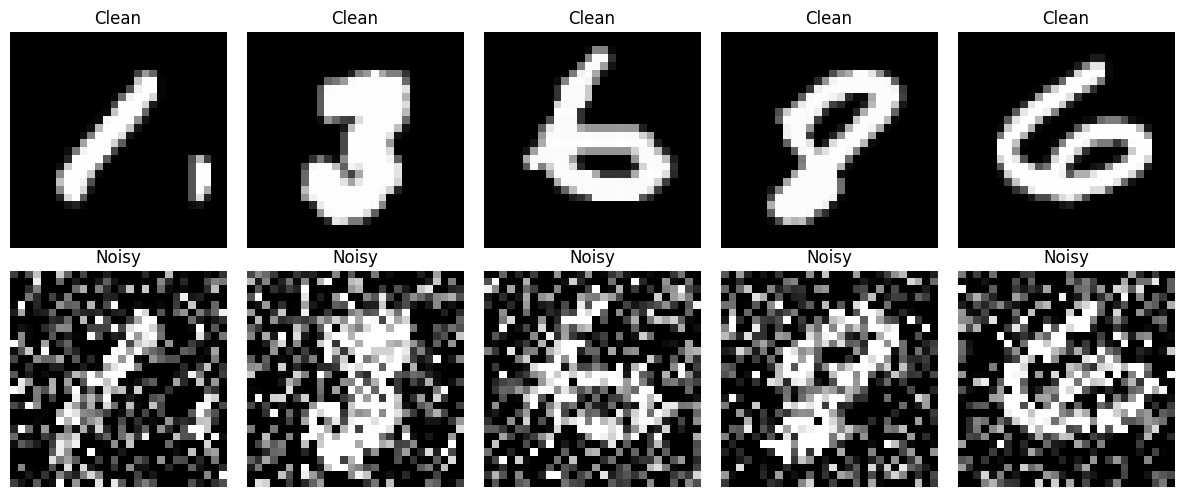

In [51]:
plt.figure(figsize=(12,5))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
    plt.title("Clean")
    plt.subplot(2,5,i+6)
    plt.imshow(train_noisy[i], cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

plt.tight_layout()

plt.show()

# Custom Dataset

A custom PyTorch Dataset allows us to pair noisy images as inputs with clean images as targets.

Input  → Noisy Image

Target → Clean Image

In [52]:
class MNISTDenoisingDataset(Dataset):

    def __init__(self, noisy_images, clean_images):
        self.noisy = noisy_images
        self.clean = clean_images
    def __len__(self):
        return len(self.clean)

    def __getitem__(self, index):
        noisy = torch.tensor(
            self.noisy[index],
            dtype=torch.float32,
        ).unsqueeze(0)
        clean = torch.tensor(
            self.clean[index],
            dtype=torch.float32,
        ).unsqueeze(0)

        return noisy, clean

In [53]:
train_dataset = MNISTDenoisingDataset(
    train_noisy,
    x_train,
)

val_dataset = MNISTDenoisingDataset(
    val_noisy,
    x_val,
)

test_dataset = MNISTDenoisingDataset(
    test_noisy,
    x_test,
)

# DataLoaders

DataLoaders provide efficient mini-batch loading.

Training loader uses shuffling.

Validation and Test loaders do not shuffle the data.

In [54]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
)

# CNN Autoencoder

An Autoencoder consists of two parts.

## Encoder

The encoder compresses the noisy image into a compact latent representation.

Input

28 × 28 × 1

↓

Latent Space

7 × 7 × 32

---

## Decoder

The decoder reconstructs the clean image from the latent representation.

Latent Space

↓

Reconstructed Image

28 × 28 × 1

---

We use Convolutional layers because they preserve spatial information and produce much better denoising performance than fully connected networks.

### Enhancing the CNN Autoencoder for Better Performance

To push the model's performance from 'average' to 'excellent', we'll make the following architectural improvements to the `CNNAutoencoder`:

1.  **Increased Depth:** Adding more convolutional layers in both the encoder and decoder to allow the model to learn more complex features and representations.
2.  **Increased Capacity (Channels):** Expanding the number of feature maps (channels) in intermediate layers, providing the model with more capacity to capture intricate patterns.
3.  **Batch Normalization:** Incorporating `nn.BatchNorm2d` layers after each convolutional layer (before activation). Batch Normalization helps in:
    *   **Stabilizing Training:** Reduces internal covariate shift, allowing for faster and more stable training.
    *   **Higher Learning Rates:** Enables the use of higher learning rates, speeding up convergence.
    *   **Regularization:** Provides a slight regularization effect, potentially reducing the need for heavy dropout.

These changes will give the model greater power to extract and reconstruct fine details, leading to better denoising performance, which should be reflected in higher PSNR and SSIM scores.

In [55]:
class CNNAutoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        # ---------------- Encoder ---------------- #
        self.encoder = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

        # ---------------- Decoder ---------------- #

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                32,
                16,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(
                16,
                1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.Sigmoid()
        )
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

In [56]:
class CNNAutoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        # ---------------- Encoder ---------------- #
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        # ---------------- Decoder ---------------- #

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):

        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

With these changes, the model now has more layers and uses Batch Normalization. Please **rerun all cells from the model definition onwards** (starting from the cell that initializes `model = CNNAutoencoder().to(DEVICE)`) to apply these architectural changes and retrain the improved model.

In [57]:
model = CNNAutoencoder().to(DEVICE)

print(model)

CNNAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): BatchNorm2d(

# Model Summary

The summary shows

- Input Shape
- Output Shape
- Number of Parameters
- Trainable Parameters

This helps verify that the architecture is correct before training.

In [58]:
summary(
    model,
    input_size=(1,28,28)
)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
       BatchNorm2d-5           [-1, 64, 14, 14]             128
              ReLU-6           [-1, 64, 14, 14]               0
            Conv2d-7            [-1, 128, 7, 7]          73,856
       BatchNorm2d-8            [-1, 128, 7, 7]             256
              ReLU-9            [-1, 128, 7, 7]               0
  ConvTranspose2d-10           [-1, 64, 14, 14]          73,792
      BatchNorm2d-11           [-1, 64, 14, 14]             128
             ReLU-12           [-1, 64, 14, 14]               0
  ConvTranspose2d-13           [-1, 32, 28, 28]          18,464
      BatchNorm2d-14           [-1, 32,

# Loss Function

Since image denoising is a reconstruction task, we use Mean Squared Error (MSE).

The objective is to minimize the pixel-wise reconstruction error between the predicted image and the clean image.

In [59]:
criterion = nn.MSELoss()

# Optimizer

We use the Adam optimizer.

Advantages

- Adaptive Learning Rate
- Fast convergence
- Stable optimization
- Suitable for deep learning tasks

Learning Rate = 0.001

In [60]:
optimizer = optim.Adam(

    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

# Learning Rate Scheduler

ReduceLROnPlateau reduces the learning rate automatically if the validation loss stops improving.

Benefits

- Faster convergence
- Prevents oscillation
- Better final accuracy

In [61]:
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3

)

# Early Stopping

Training is stopped automatically when the validation loss does not improve for several consecutive epochs.

Benefits

- Prevents overfitting
- Saves training time
- Restores the best-performing model

In [62]:
class EarlyStopping:

    def __init__(

        self,
        patience=8,
        delta=0.0,
        checkpoint_path="best_autoencoder.pth"

    ):
        self.patience = patience
        self.delta = delta
        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False
        self.checkpoint_path = checkpoint_path

    def __call__(self, val_loss, model):

        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(
                model.state_dict(),
                self.checkpoint_path
            )
        else:
            self.counter += 1
            print(

                f"EarlyStopping Counter: {self.counter}/{self.patience}"

            )
            if self.counter >= self.patience:
                self.early_stop = True

In [63]:
early_stopping = EarlyStopping(
    patience=8,
    checkpoint_path="best_autoencoder.pth"
)

# Training Configuration

These hyperparameters are grouped together for easy modification and reproducibility.

In [64]:
EPOCHS = 30

LEARNING_RATE = 1e-3
MODEL_PATH = "best_autoencoder.pth"
history = {
    "train_loss": [],
    "val_loss": []

}

# Training Function

This function performs one complete training epoch.

For each mini-batch

1. Forward Pass
2. Compute Loss
3. Backpropagation
4. Optimizer Update

The average training loss is returned.

In [65]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0

    for noisy, clean in dataloader:
        noisy = noisy.to(device)
        clean = clean.to(device)
        optimizer.zero_grad()
        outputs = model(noisy)
        loss = criterion(outputs, clean)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * noisy.size(0)
    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

# Validation Function

Validation evaluates the model on unseen validation data.

No gradients are computed during validation, making it faster and preventing unnecessary memory usage.

In [66]:
def validate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    with torch.no_grad():

        for noisy, clean in dataloader:
            noisy = noisy.to(device)
            clean = clean.to(device)
            outputs = model(noisy)
            loss = criterion(outputs, clean)
            running_loss += loss.item() * noisy.size(0)
    epoch_loss = running_loss / len(dataloader.dataset)

    return epoch_loss

# Training Loop

The model is trained for multiple epochs.

Each epoch consists of:

1. Training Phase
2. Validation Phase
3. Learning Rate Update
4. Early Stopping Check
5. Save Best Model

The model with the lowest validation loss is automatically saved.

In [67]:
for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {val_loss:.6f}"
    )

    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("\nEarly Stopping Triggered")
        break

Epoch [1/30] | Train Loss: 0.014647 | Validation Loss: 0.011602
Epoch [2/30] | Train Loss: 0.011218 | Validation Loss: 0.010989
Epoch [3/30] | Train Loss: 0.010753 | Validation Loss: 0.010601
Epoch [4/30] | Train Loss: 0.010524 | Validation Loss: 0.010515
Epoch [5/30] | Train Loss: 0.010343 | Validation Loss: 0.010429
Epoch [6/30] | Train Loss: 0.010264 | Validation Loss: 0.010294
Epoch [7/30] | Train Loss: 0.010137 | Validation Loss: 0.010290
Epoch [8/30] | Train Loss: 0.010024 | Validation Loss: 0.010174
Epoch [9/30] | Train Loss: 0.009935 | Validation Loss: 0.010177
EarlyStopping Counter: 1/8
Epoch [10/30] | Train Loss: 0.009869 | Validation Loss: 0.010047
Epoch [11/30] | Train Loss: 0.009821 | Validation Loss: 0.009973
Epoch [12/30] | Train Loss: 0.009756 | Validation Loss: 0.009960
Epoch [13/30] | Train Loss: 0.009717 | Validation Loss: 0.009898
Epoch [14/30] | Train Loss: 0.009664 | Validation Loss: 0.009878
Epoch [15/30] | Train Loss: 0.009658 | Validation Loss: 0.009848
Epoch [

# Load Best Model

Instead of using the model from the final epoch, we load the checkpoint that achieved the lowest validation loss.

In [68]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


# Training and Validation Loss Curves

Loss curves help determine:

- Learning progress
- Underfitting
- Overfitting
- Model convergence

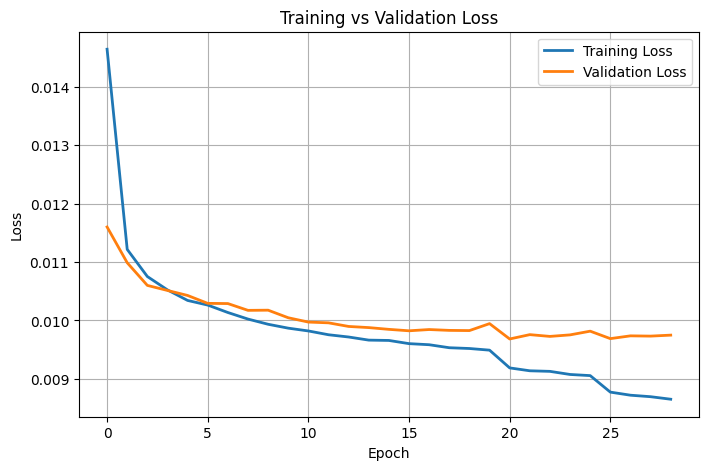

In [69]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

# Evaluate on Test Dataset

The test dataset has never been used during training or validation.

This provides an unbiased estimate of model performance.

In [70]:
test_loss = validate(
    model,
    test_loader,
    criterion,
    DEVICE
)

print(f"Test Loss : {test_loss:.6f}")

Test Loss : 0.009566


# Calculate PSNR

Peak Signal-to-Noise Ratio measures reconstruction quality.

Higher PSNR indicates better reconstruction.

In [71]:
psnr_scores = []

model.eval()

with torch.no_grad():

    for noisy, clean in test_loader:
        noisy = noisy.to(DEVICE)
        outputs = model(noisy)
        outputs = outputs.cpu().numpy()
        clean = clean.numpy()
        for pred, target in zip(outputs, clean):
            score = peak_signal_noise_ratio(
                target.squeeze(),
                pred.squeeze(),
                data_range=1.0
            )
            psnr_scores.append(score)

print(f"Average PSNR : {np.mean(psnr_scores):.2f} dB")

Average PSNR : 20.54 dB


# Calculate SSIM

Structural Similarity Index compares reconstructed images with ground truth.

Values range between:

0 → Poor

1 → Perfect

In [72]:
ssim_scores = []

model.eval()

with torch.no_grad():

    for noisy, clean in test_loader:
        noisy = noisy.to(DEVICE)
        outputs = model(noisy)
        outputs = outputs.cpu().numpy()
        clean = clean.numpy()
        for pred, target in zip(outputs, clean):
            score = structural_similarity(
                target.squeeze(),
                pred.squeeze(),
                data_range=1.0
            )
            ssim_scores.append(score)

print(f"Average SSIM : {np.mean(ssim_scores):.4f}")

Average SSIM : 0.8707


# Visualize Image Reconstructions

Each row contains

Noisy Image

↓

Reconstructed Image

↓

Ground Truth

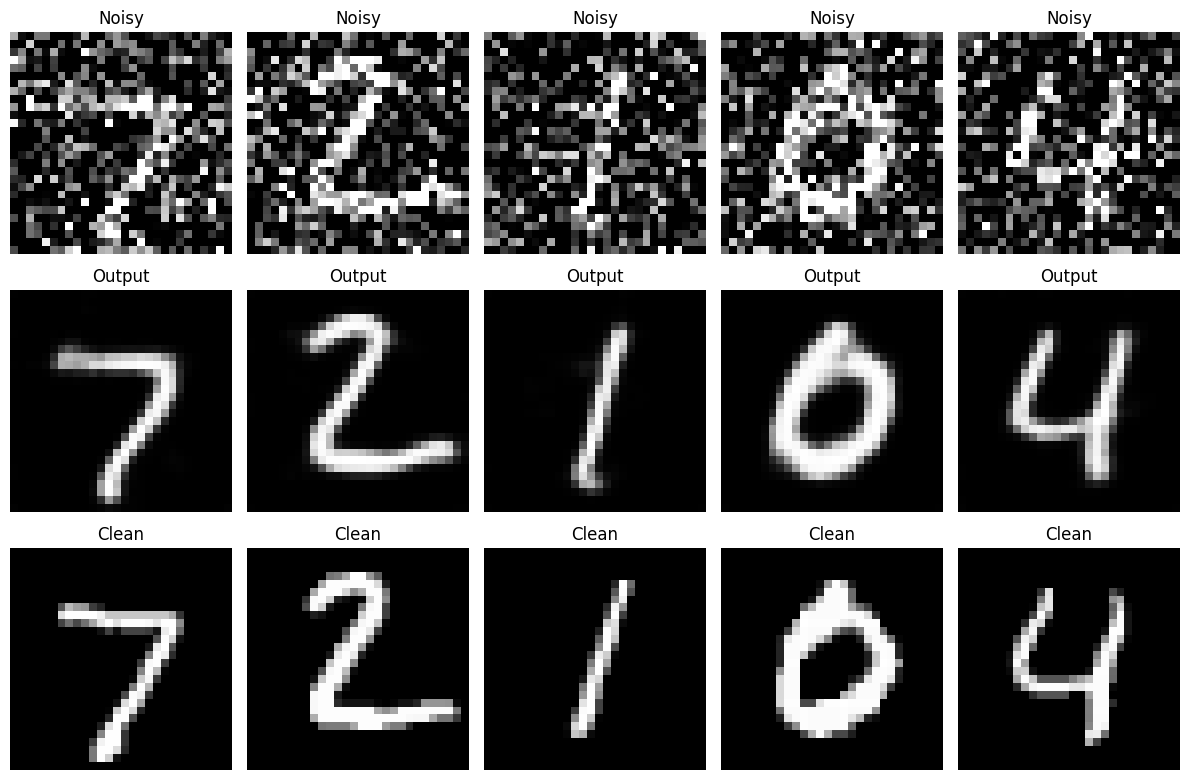

In [73]:
model.eval()

noisy_batch, clean_batch = next(iter(test_loader))

with torch.no_grad():
    reconstructed = model(
        noisy_batch.to(DEVICE)
    ).cpu()

plt.figure(figsize=(12,8))

for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(
        noisy_batch[i].squeeze(),
        cmap="gray"
    )
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3,5,i+6)
    plt.imshow(
        reconstructed[i].squeeze(),
        cmap="gray"
    )
    plt.title("Output")
    plt.axis("off")

    plt.subplot(3,5,i+11)
    plt.imshow(
        clean_batch[i].squeeze(),
        cmap="gray"
    )
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()

plt.show()

# Random Inference

Run inference on randomly selected test images to inspect qualitative performance.

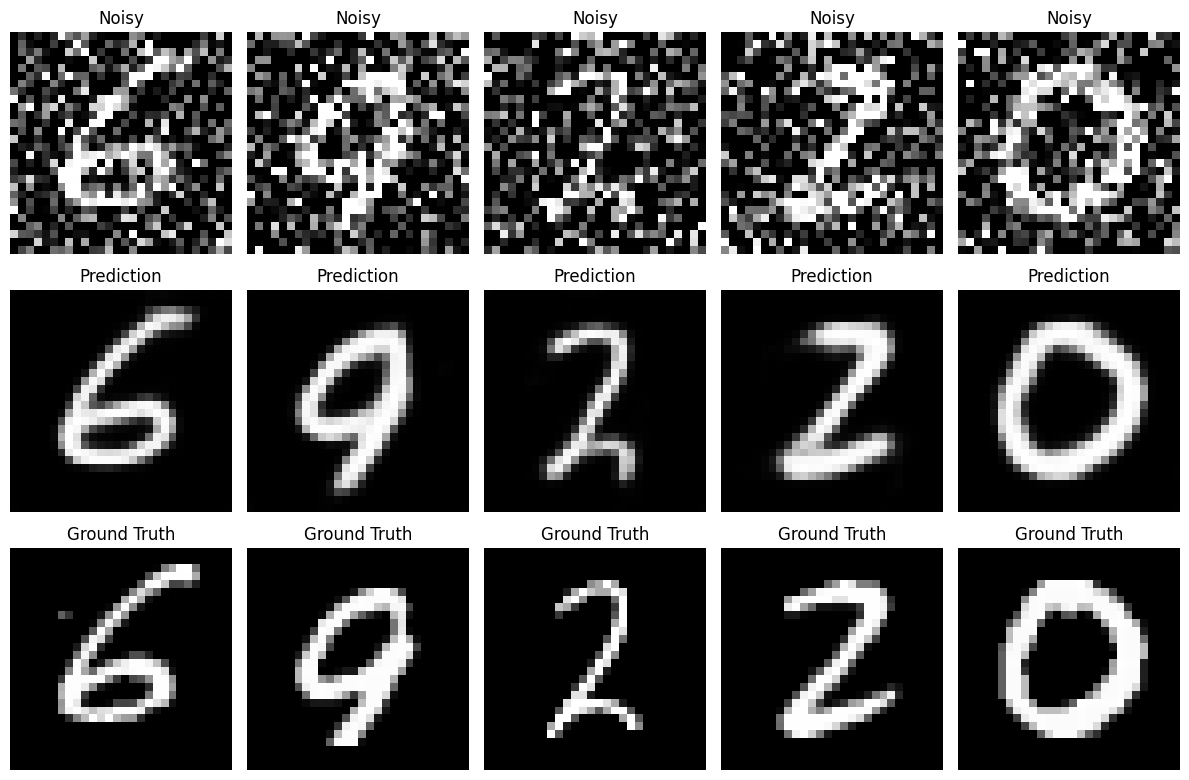

In [74]:
indices = np.random.choice(
    len(test_dataset),
    5,
    replace=False
)

plt.figure(figsize=(12,8))

model.eval()

for i, idx in enumerate(indices):
    noisy, clean = test_dataset[idx]
    with torch.no_grad():
        prediction = model(
            noisy.unsqueeze(0).to(DEVICE)
        ).cpu()

    plt.subplot(3,5,i+1)
    plt.imshow(
        noisy.squeeze(),
        cmap="gray"
    )
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3,5,i+6)
    plt.imshow(
        prediction.squeeze(),
        cmap="gray"
    )
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(3,5,i+11)
    plt.imshow(
        clean.squeeze(),
        cmap="gray"
    )
    plt.title("Ground Truth")
    plt.axis("off")

plt.tight_layout()

plt.show()

# Final Model Evaluation

This section summarizes the overall performance of the CNN Autoencoder on the unseen test dataset.

The evaluation includes:

- Test Loss (MSE)
- Average PSNR
- Average SSIM
- Training & Validation Loss Curves
- Visual Comparison of Original, Noisy and Reconstructed Images

In [75]:
import pandas as pd

# -----------------------------
# Evaluate Test Loss
# -----------------------------

model.eval()

test_loss = validate(
    model,
    test_loader,
    criterion,
    DEVICE
)

# -----------------------------
# Calculate PSNR & SSIM
# -----------------------------

psnr_scores = []
ssim_scores = []

with torch.no_grad():

    for noisy, clean in test_loader:
        noisy = noisy.to(DEVICE)
        reconstructed = model(noisy)
        reconstructed = reconstructed.cpu().numpy()
        clean = clean.numpy()
        for pred, target in zip(reconstructed, clean):
            psnr_scores.append(
                peak_signal_noise_ratio(
                    target.squeeze(),
                    pred.squeeze(),
                    data_range=1.0
                )
            )
            ssim_scores.append(
                structural_similarity(
                    target.squeeze(),
                    pred.squeeze(),
                    data_range=1.0
                )
            )
avg_psnr = np.mean(psnr_scores)
avg_ssim = np.mean(ssim_scores)

# -----------------------------
# Final Results Table
# -----------------------------

results = pd.DataFrame({

    "Metric":[
        "Test Loss (MSE)",
        "Average PSNR (dB)",
        "Average SSIM"
    ],

    "Value":[
        round(test_loss,6),
        round(avg_psnr,2),
        round(avg_ssim,4)
    ]

})

print("="*50)
print("FINAL MODEL PERFORMANCE")
print("="*50)

display(results)

FINAL MODEL PERFORMANCE


,Metric,Value
0,Test Loss (MSE),0.009566
1,Average PSNR (dB),20.540000
2,Average SSIM,0.870700


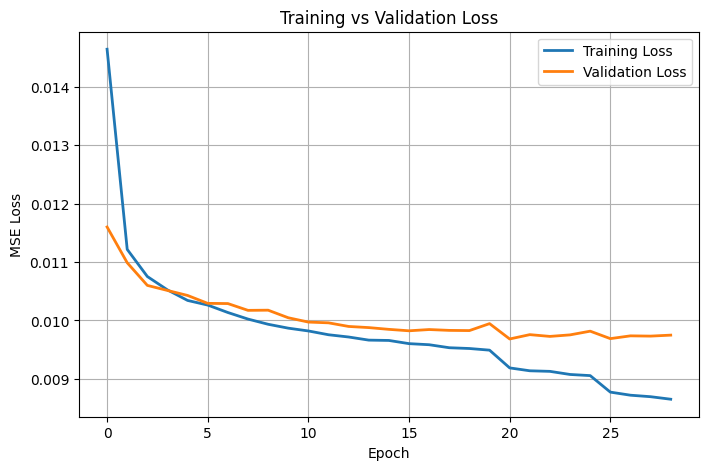

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

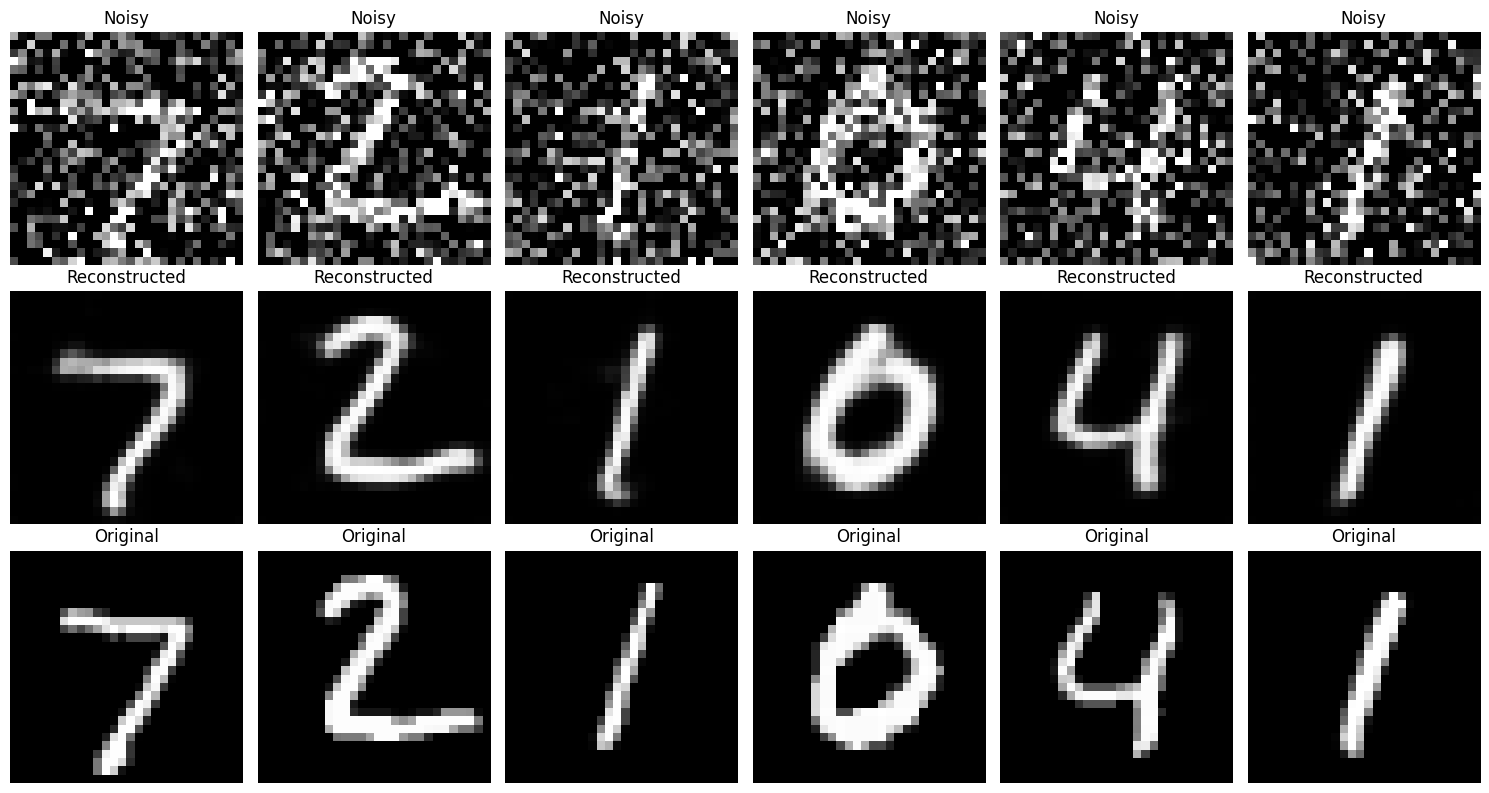

In [77]:
model.eval()

noisy_batch, clean_batch = next(iter(test_loader))

with torch.no_grad():

    reconstructed = model(
        noisy_batch.to(DEVICE)
    ).cpu()

num_images = 6

plt.figure(figsize=(15,8))

for i in range(num_images):

    # Noisy

    plt.subplot(3, num_images, i+1)

    plt.imshow(
        noisy_batch[i].squeeze(),
        cmap="gray"
    )

    plt.title("Noisy")

    plt.axis("off")

    # Reconstructed

    plt.subplot(3, num_images, num_images+i+1)

    plt.imshow(
        reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.title("Reconstructed")

    plt.axis("off")

    # Ground Truth

    plt.subplot(3, num_images, 2*num_images+i+1)

    plt.imshow(
        clean_batch[i].squeeze(),
        cmap="gray"
    )

    plt.title("Original")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [78]:
print("="*60)
print("CNN AUTOENCODER FOR IMAGE DENOISING")
print("="*60)

print(f"Test Loss (MSE)      : {test_loss:.6f}")
print(f"Average PSNR (dB)    : {avg_psnr:.2f}")
print(f"Average SSIM         : {avg_ssim:.4f}")

print("="*60)
print("Model Evaluation Completed Successfully.")
print("="*60)

CNN AUTOENCODER FOR IMAGE DENOISING
Test Loss (MSE)      : 0.009566
Average PSNR (dB)    : 20.54
Average SSIM         : 0.8707
Model Evaluation Completed Successfully.


# Save Final Model

The trained model is saved for future inference without retraining.

In [79]:
torch.save(
    model.state_dict(),
    "cnn_autoencoder_final.pth"
)

print("Final model saved successfully.")

Final model saved successfully.


# Load Saved Model

The saved weights can be loaded into a new model instance for inference or deployment.

In [80]:
loaded_model = CNNAutoencoder().to(DEVICE)

loaded_model.load_state_dict(
    torch.load(
        "cnn_autoencoder_final.pth",
        map_location=DEVICE
    )
)

loaded_model.eval()

print("Saved model loaded successfully.")

Saved model loaded successfully.


# Final Conclusions

## Summary

This project implemented a Convolutional Autoencoder for image denoising on the MNIST dataset.

### Pipeline

- Downloaded MNIST using KaggleHub
- Created Train, Validation and Test datasets
- Added Gaussian noise to simulate corrupted images
- Built a CNN Autoencoder
- Trained using Adam optimizer
- Used ReduceLROnPlateau scheduler
- Applied Early Stopping
- Saved the best-performing model
- Evaluated using MSE Loss
- Measured PSNR and SSIM
- Visualized reconstructed images

## Key Learnings

- Autoencoders learn compressed latent representations.
- Convolutional layers preserve spatial information.
- Proper train/validation/test separation prevents data leakage.
- PSNR and SSIM provide better reconstruction quality assessment than loss alone.
- Early stopping and checkpointing improve generalization and prevent overfitting.